In [2]:
import pandas as pd

print("Pandas version:", pd.__version__)

Pandas version: 3.0.6


** Data_Driven_Social_Engagement
│
├── data
│   ├── raw
│   │   ├── Cleaned_Viral_Social_Media_Trends.csv
│   │   └── Social media_Data.csv
│   └── processed
│
├── notebooks
│   └── 01_data_inspection.ipynb
│
├── src
├── outputs
├── dashboard
├── docs
├── .venv
└── requirements.txt **
 

In [3]:
import os

data_path = "../data/raw"

print("Files in data/raw:")
print(os.listdir(data_path))

Files in data/raw:
['Cleaned_Viral_Social_Media_Trends.csv', 'Social media_Data.csv']


In [4]:
import pandas as pd

viral_df = pd.read_csv("../data/raw/Cleaned_Viral_Social_Media_Trends.csv")
sentiment_df = pd.read_csv("../data/raw/Social media_Data.csv")

print("Viral Dataset:")
print("Shape:", viral_df.shape)
print("Columns:", viral_df.columns.tolist())

print("\nSentiment Dataset:")
print("Shape:", sentiment_df.shape)
print("Columns:", sentiment_df.columns.tolist())

Viral Dataset:
Shape: (5000, 11)
Columns: ['Post_ID', 'Post_Date', 'Platform', 'Hashtag', 'Content_Type', 'Region', 'Views', 'Likes', 'Shares', 'Comments', 'Engagement_Level']

Sentiment Dataset:
Shape: (37249, 2)
Columns: ['clean_comment', 'category']


In [5]:
print("VIRAL DATASET")
display(viral_df.head())

print("\nSENTIMENT DATASET")
display(sentiment_df.head())


VIRAL DATASET


,Post_ID,Post_Date,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,2022-01-13,TikTok,#Challenge,Video,UK,4163464,339431,53135,19346,High
1,Post_2,2022-05-13,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium
2,Post_3,2022-01-07,Twitter,#Challenge,Video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,2022-12-05,YouTube,#Education,Shorts,Australia,917951,127125,11687,36806,Low
4,Post_5,2023-03-23,TikTok,#Dance,Post,Brazil,64866,171361,69581,6376,Medium



SENTIMENT DATASET


,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [6]:
print("VIRAL DATASET - MISSING VALUES")
print(viral_df.isnull().sum())

print("\nSENTIMENT DATASET - MISSING VALUES")
print(sentiment_df.isnull().sum())

VIRAL DATASET - MISSING VALUES
Post_ID             0
Post_Date           0
Platform            0
Hashtag             0
Content_Type        0
Region              0
Views               0
Likes               0
Shares              0
Comments            0
Engagement_Level    0
dtype: int64

SENTIMENT DATASET - MISSING VALUES
clean_comment    100
category           0
dtype: int64


In [7]:
print("VIRAL DATASET")
print("Duplicate rows:", viral_df.duplicated().sum())
print("Duplicate Post_IDs:", viral_df["Post_ID"].duplicated().sum())

print("\nSENTIMENT DATASET")
print("Duplicate rows:", sentiment_df.duplicated().sum())
print("Duplicate comments:", sentiment_df["clean_comment"].duplicated().sum())

VIRAL DATASET
Duplicate rows: 0
Duplicate Post_IDs: 0

SENTIMENT DATASET
Duplicate rows: 449
Duplicate comments: 449


In [8]:
print("Sentiment category counts:")
print(sentiment_df["category"].value_counts())

print("\nUnique category values:")
print(sentiment_df["category"].unique())

Sentiment category counts:
category
 1    15830
 0    13142
-1     8277
Name: count, dtype: int64

Unique category values:
[ 1 -1  0]


In [9]:
print("Platform:")
print(viral_df["Platform"].value_counts())

print("\nContent Type:")
print(viral_df["Content_Type"].value_counts())

print("\nRegion:")
print(viral_df["Region"].value_counts())

print("\nEngagement Level:")
print(viral_df["Engagement_Level"].value_counts())

Platform:
Platform
YouTube      1324
TikTok       1260
Instagram    1212
Twitter      1204
Name: count, dtype: int64

Content Type:
Content_Type
Live Stream    855
Post           853
Reel           841
Tweet          836
Video          828
Shorts         787
Name: count, dtype: int64

Region:
Region
USA          677
Canada       658
UK           647
Brazil       641
India        617
Australia    602
Japan        592
Germany      566
Name: count, dtype: int64

Engagement Level:
Engagement_Level
Low       1729
High      1673
Medium    1598
Name: count, dtype: int64


In [10]:
print("Numerical columns summary:")
display(viral_df[["Views", "Likes", "Shares", "Comments"]].describe())

Numerical columns summary:


,Views,Likes,Shares,Comments
count,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,2.494066e+06,251475.029800,50519.562000,24888.393800
std,1.459490e+06,144349.583384,29066.362671,14284.504319
min,1.266000e+03,490.000000,52.000000,18.000000
25%,1.186207e+06,126892.250000,25029.000000,12305.250000
50%,2.497373e+06,249443.000000,50839.500000,25004.000000
75%,3.759781e+06,373970.750000,75774.250000,37072.750000
max,4.999430e+06,499922.000000,99978.000000,49993.000000


In [11]:
print("VIRAL DATASET DATA TYPES")
print(viral_df.dtypes)

print("\nSENTIMENT DATASET DATA TYPES")
print(sentiment_df.dtypes)


VIRAL DATASET DATA TYPES
Post_ID               str
Post_Date             str
Platform              str
Hashtag               str
Content_Type          str
Region                str
Views               int64
Likes               int64
Shares              int64
Comments            int64
Engagement_Level      str
dtype: object

SENTIMENT DATASET DATA TYPES
clean_comment      str
category         int64
dtype: object


In [12]:
viral_df["Post_Date"] = pd.to_datetime(viral_df["Post_Date"])

print(viral_df["Post_Date"].dtype)
print(viral_df["Post_Date"].head())

datetime64[us]
0   2022-01-13
1   2022-05-13
2   2022-01-07
3   2022-12-05
4   2023-03-23
Name: Post_Date, dtype: datetime64[us]


In [13]:
print("Earliest post date:", viral_df["Post_Date"].min())
print("Latest post date:", viral_df["Post_Date"].max())
print("Number of unique dates:", viral_df["Post_Date"].nunique())


Earliest post date: 2022-01-01 00:00:00
Latest post date: 2023-12-30 00:00:00
Number of unique dates: 729


Next step — check whether any numerical values are suspicious

In [14]:
print("Rows with zero or negative values:")

for col in ["Views", "Likes", "Shares", "Comments"]:
    print(f"{col}: {(viral_df[col] <= 0).sum()}")

Rows with zero or negative values:
Views: 0
Likes: 0
Shares: 0
Comments: 0


check for unrealistic engagement relationships

In [15]:
print("Likes greater than Views:", (viral_df["Likes"] > viral_df["Views"]).sum())
print("Shares greater than Views:", (viral_df["Shares"] > viral_df["Views"]).sum())
print("Comments greater than Views:", (viral_df["Comments"] > viral_df["Views"]).sum())

Likes greater than Views: 268
Shares greater than Views: 50
Comments greater than Views: 25


In [16]:
suspicious_data = viral_df[
    (viral_df["Likes"] > viral_df["Views"]) |
    (viral_df["Shares"] > viral_df["Views"]) |
    (viral_df["Comments"] > viral_df["Views"])
]

print("Suspicious records:", len(suspicious_data))

display(
    suspicious_data[
        ["Post_ID", "Views", "Likes", "Shares", "Comments"]
    ].head(10)
)

Suspicious records: 270


,Post_ID,Views,Likes,Shares,Comments
4,Post_5,64866,171361,69581,6376
20,Post_21,14095,268310,90495,16968
36,Post_37,48908,205884,37256,14618
45,Post_46,272327,274271,56073,17526
81,Post_82,284772,338933,22771,18899
94,Post_95,128472,444670,64311,7956
96,Post_97,92085,176687,5641,22316
104,Post_105,13562,11483,33641,30457
143,Post_144,50082,70708,277,25036
153,Post_154,41081,319140,6541,23057


save a copy of the original data

Before we start cleaning, let's create working copies so the original loaded data remains untouched.

In [17]:
viral_clean = viral_df.copy()
sentiment_clean = sentiment_df.copy()

print("Viral clean shape:", viral_clean.shape)
print("Sentiment clean shape:", sentiment_clean.shape)

Viral clean shape: (5000, 11)
Sentiment clean shape: (37249, 2)


In [18]:
sentiment_clean = sentiment_clean.dropna(subset=["clean_comment"])

print("Shape after removing missing comments:", sentiment_clean.shape)
print("Missing comments:", sentiment_clean["clean_comment"].isna().sum())

Shape after removing missing comments: (37149, 2)
Missing comments: 0


In [19]:
sentiment_clean = sentiment_clean.drop_duplicates(
    subset=["clean_comment"],
    keep="first"
)

print("Shape after removing duplicates:", sentiment_clean.shape)
print("Duplicate comments remaining:",
      sentiment_clean["clean_comment"].duplicated().sum())

Shape after removing duplicates: (36799, 2)
Duplicate comments remaining: 0


In [20]:
print("Cleaned sentiment distribution:")
print(sentiment_clean["category"].value_counts())

print("\nPercentage distribution:")
print(
    sentiment_clean["category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Cleaned sentiment distribution:
category
 1    15771
 0    12778
-1     8250
Name: count, dtype: int64

Percentage distribution:
category
 1    42.86
 0    34.72
-1    22.42
Name: proportion, dtype: float64


check text quality

Before NLP preprocessing, let's check whether the comments contain empty strings or whitespace-only values

In [21]:
empty_comments = (
    sentiment_clean["clean_comment"]
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("Empty or whitespace-only comments:", empty_comments)

Empty or whitespace-only comments: 6


In [22]:
sentiment_clean["clean_comment"] = (
    sentiment_clean["clean_comment"]
    .astype(str)
    .str.strip()
)

sentiment_clean = sentiment_clean[
    sentiment_clean["clean_comment"] != ""
].copy()

print("Final sentiment dataset shape:", sentiment_clean.shape)
print(
    "Empty comments remaining:",
    sentiment_clean["clean_comment"].eq("").sum()
)

Final sentiment dataset shape: (36793, 2)
Empty comments remaining: 0


In [23]:
print("Unique Platforms:")
print(viral_clean["Platform"].unique())

print("\nUnique Content Types:")
print(viral_clean["Content_Type"].unique())

print("\nUnique Engagement Levels:")
print(viral_clean["Engagement_Level"].unique())

Unique Platforms:
<StringArray>
['TikTok', 'Instagram', 'Twitter', 'YouTube']
Length: 4, dtype: str

Unique Content Types:
<StringArray>
['Video', 'Shorts', 'Post', 'Tweet', 'Live Stream', 'Reel']
Length: 6, dtype: str

Unique Engagement Levels:
<StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str


In [24]:
print("Hashtags:")
print(viral_clean["Hashtag"].unique())

print("\nRegions:")
print(viral_clean["Region"].unique())

Hashtags:
<StringArray>
['#Challenge', '#Education',     '#Dance',    '#Comedy',    '#Gaming',
     '#Music',     '#Viral',   '#Fitness',      '#Tech',   '#Fashion']
Length: 10, dtype: str

Regions:
<StringArray>
['UK', 'India', 'Brazil', 'Australia', 'Japan', 'Germany', 'Canada', 'USA']
Length: 8, dtype: str


In [25]:
print("Final Sentiment Distribution:")
print(sentiment_clean["category"].value_counts())

print("\nFinal Sentiment Percentages:")
print(
    (sentiment_clean["category"].value_counts(normalize=True) * 100)
    .round(2)
)

Final Sentiment Distribution:
category
 1    15771
 0    12772
-1     8250
Name: count, dtype: int64

Final Sentiment Percentages:
category
 1    42.86
 0    34.71
-1    22.42
Name: proportion, dtype: float64


create engagement features

Now we'll start transforming the viral dataset into useful analytics features.

In [26]:
viral_clean["Engagement_Rate"] = (
    (viral_clean["Likes"] + viral_clean["Shares"] + viral_clean["Comments"])
    / viral_clean["Views"]
) * 100

viral_clean["Share_Rate"] = (
    viral_clean["Shares"] / viral_clean["Views"]
) * 100

viral_clean["Comment_Rate"] = (
    viral_clean["Comments"] / viral_clean["Views"]
) * 100

viral_clean[[
    "Post_ID",
    "Views",
    "Likes",
    "Shares",
    "Comments",
    "Engagement_Rate",
    "Share_Rate",
    "Comment_Rate"
]].head()

,Post_ID,Views,Likes,Shares,Comments,Engagement_Rate,Share_Rate,Comment_Rate
0,Post_1,4163464,339431,53135,19346,9.893493,1.276221,0.464661
1,Post_2,4155940,215240,65860,27239,7.419236,1.584720,0.655423
2,Post_3,3666211,327143,39423,36223,10.986520,1.075306,0.988023
3,Post_4,917951,127125,11687,36806,19.131522,1.273162,4.009582
4,Post_5,64866,171361,69581,6376,381.275244,107.268831,9.829495


inspect the engagement-rate distribution

In [27]:
print("Engagement Rate Summary:")
print(viral_clean["Engagement_Rate"].describe())

print("\nShare Rate Summary:")
print(viral_clean["Share_Rate"].describe())

print("\nComment Rate Summary:")
print(viral_clean["Comment_Rate"].describe())

Engagement Rate Summary:
count     5000.000000
mean        56.759851
std        486.213959
min          0.300122
25%          7.748975
50%         12.909687
75%         27.001840
max      28174.170616
Name: Engagement_Rate, dtype: float64

Share Rate Summary:
count    5000.000000
mean        8.051449
std        50.025577
min         0.001261
25%         1.024274
50%         2.004027
75%         4.106744
max      1891.880638
Name: Share_Rate, dtype: float64

Comment Rate Summary:
count    5000.000000
mean        4.540457
std        46.603589
min         0.001576
25%         0.501340
50%         1.002971
75%         2.030583
max      2853.159558
Name: Comment_Rate, dtype: float64


identify the extreme engagement records

In [28]:
extreme_engagement = viral_clean.nlargest(
    10, "Engagement_Rate"
)[[
    "Post_ID",
    "Views",
    "Likes",
    "Shares",
    "Comments",
    "Engagement_Rate"
]]

extreme_engagement

,Post_ID,Views,Likes,Shares,Comments,Engagement_Rate
4826,Post_4827,1266,318849,1715,36121,28174.170616
1540,Post_1541,4323,301571,81786,30318,9569.164932
3686,Post_3687,5467,337597,79716,33748,8250.612768
2647,Post_2648,8982,353646,77267,39542,5237.753284
4691,Post_4692,8162,285470,60984,43541,4778.179368
1033,Post_1034,11338,379782,86100,44273,4499.514906
4991,Post_4992,10157,322897,93292,23766,4331.544747
4137,Post_4138,13578,485916,39122,29109,4081.212255
4284,Post_4285,7810,277197,12486,422,3714.532650
4571,Post_4572,5679,95171,63079,40180,3494.101074


In [29]:
viral_clean["Engagement_Anomaly"] = (
    (viral_clean["Likes"] > viral_clean["Views"]) |
    (viral_clean["Shares"] > viral_clean["Views"]) |
    (viral_clean["Comments"] > viral_clean["Views"])
)

print("Engagement anomalies:", viral_clean["Engagement_Anomaly"].sum())
print("Normal records:", (~viral_clean["Engagement_Anomaly"]).sum())

Engagement anomalies: 270
Normal records: 4730


In [30]:
# Calculate Viral Coefficient

viral_clean["Viral_Coefficient"] = (
    0.60 * (viral_clean["Shares"] / viral_clean["Views"]) +
    0.20 * (viral_clean["Comments"] / viral_clean["Views"]) +
    0.20 * (viral_clean["Likes"] / viral_clean["Views"])
)

In [31]:
# Calculate Virality Score

viral_clean["Virality_Score"] = (
    viral_clean["Viral_Coefficient"] * 100
)

In [33]:
print(viral_clean[[
    "Post_ID",
    "Views",
    "Likes",
    "Shares",
    "Comments",
    "Viral_Coefficient",
    "Virality_Score"
]].head(10))

   Post_ID    Views   Likes  Shares  Comments  Viral_Coefficient  \
0   Post_1  4163464  339431   53135     19346           0.024892   
1   Post_2  4155940  215240   65860     27239           0.021177   
2   Post_3  3666211  327143   39423     36223           0.026274   
3   Post_4   917951  127125   11687     36806           0.043356   
4   Post_5    64866  171361   69581      6376           1.191626   
5   Post_6  1323566  136282   86979     47129           0.067144   
6   Post_7   627233   84121   97973     32648           0.130952   
7   Post_8  2066886  317502   45222     33638           0.047105   
8   Post_9  2169523  496078   96041     30174           0.075074   
9  Post_10  3898384    8634   69378     42700           0.013312   

   Virality_Score  
0        2.489187  
1        2.117735  
2        2.627427  
3        4.335569  
4      119.162581  
5        6.714406  
6       13.095229  
7        4.710526  
8        7.507411  
9        1.331157  


In [34]:
top_virality = viral_clean.nlargest(
    10, "Virality_Score"
)[[
    "Post_ID",
    "Platform",
    "Hashtag",
    "Content_Type",
    "Region",
    "Views",
    "Likes",
    "Shares",
    "Comments",
    "Viral_Coefficient",
    "Virality_Score"
]]

top_virality

,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Viral_Coefficient,Virality_Score
4826,Post_4827,TikTok,#Viral,Shorts,USA,1266,318849,1715,36121,56.890205,5689.020537
1540,Post_1541,Instagram,#Comedy,Live Stream,Japan,4323,301571,81786,30318,26.705852,2670.585242
3686,Post_3687,YouTube,#Tech,Live Stream,UK,5467,337597,79716,33748,22.333748,2233.374794
2647,Post_2648,YouTube,#Challenge,Post,USA,8982,353646,77267,39542,13.916477,1391.647740
4691,Post_4692,Twitter,#Education,Shorts,India,8162,285470,60984,43541,12.545038,1254.503798
4991,Post_4992,Instagram,#Fashion,Shorts,Brazil,10157,322897,93292,23766,12.337088,1233.708772
1033,Post_1034,Instagram,#Education,Tweet,Australia,11338,379782,86100,44273,12.036603,1203.660258
4571,Post_4572,TikTok,#Gaming,Video,USA,5679,95171,63079,40180,11.431167,1143.116746
4137,Post_4138,Instagram,#Comedy,Tweet,Canada,13578,485916,39122,29109,9.314936,931.493593
4771,Post_4772,Instagram,#Viral,Reel,Australia,17410,440302,87598,7090,8.158369,815.836875


In [35]:

platform_virality = (
    viral_clean.groupby("Platform")["Virality_Score"]
    .agg(["mean", "median", "max", "count"])
    .round(2)
    .sort_values("mean", ascending=False)
)

platform_virality

,mean,median,max,count
Platform,,,,
Instagram,17.56,3.55,2670.59,1212
TikTok,15.72,3.26,5689.02,1260
YouTube,13.09,3.35,2233.37,1324
Twitter,11.99,3.30,1254.50,1204


In [36]:
content_virality = (
    viral_clean.groupby("Content_Type")["Virality_Score"]
    .agg(["mean", "median", "max", "count"])
    .round(2)
    .sort_values("mean", ascending=False)
)

content_virality

,mean,median,max,count
Content_Type,,,,
Shorts,18.98,3.40,5689.02,787
Live Stream,16.40,3.47,2670.59,855
Tweet,13.78,3.26,1203.66,836
Post,13.18,3.34,1391.65,853
Video,13.00,3.37,1143.12,828
Reel,12.33,3.48,815.84,841


In [37]:
hashtag_virality = (
    viral_clean.groupby("Hashtag")["Virality_Score"]
    .agg(["mean", "median", "max", "count"])
    .round(2)
    .sort_values("mean", ascending=False)
)

hashtag_virality

,mean,median,max,count
Hashtag,,,,
#Viral,22.96,3.54,5689.02,481
#Comedy,17.78,3.56,2670.59,505
#Gaming,16.70,3.25,1143.12,479
#Fitness,14.02,3.16,635.68,536
#Tech,13.93,3.31,2233.37,491
#Education,13.43,3.39,1254.50,525
#Fashion,12.88,3.53,1233.71,487
#Dance,12.23,3.44,528.94,496
#Challenge,12.15,3.23,1391.65,507


In [38]:
top_20_viral = (
    viral_clean.nlargest(20, "Virality_Score")
    [[
        "Post_ID",
        "Platform",
        "Hashtag",
        "Content_Type",
        "Region",
        "Views",
        "Likes",
        "Shares",
        "Comments",
        "Viral_Coefficient",
        "Virality_Score"
    ]]
)

top_20_viral

,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Viral_Coefficient,Virality_Score
4826,Post_4827,TikTok,#Viral,Shorts,USA,1266,318849,1715,36121,56.890205,5689.020537
1540,Post_1541,Instagram,#Comedy,Live Stream,Japan,4323,301571,81786,30318,26.705852,2670.585242
3686,Post_3687,YouTube,#Tech,Live Stream,UK,5467,337597,79716,33748,22.333748,2233.374794
2647,Post_2648,YouTube,#Challenge,Post,USA,8982,353646,77267,39542,13.916477,1391.647740
4691,Post_4692,Twitter,#Education,Shorts,India,8162,285470,60984,43541,12.545038,1254.503798
4991,Post_4992,Instagram,#Fashion,Shorts,Brazil,10157,322897,93292,23766,12.337088,1233.708772
1033,Post_1034,Instagram,#Education,Tweet,Australia,11338,379782,86100,44273,12.036603,1203.660258
4571,Post_4572,TikTok,#Gaming,Video,USA,5679,95171,63079,40180,11.431167,1143.116746
4137,Post_4138,Instagram,#Comedy,Tweet,Canada,13578,485916,39122,29109,9.314936,931.493593
4771,Post_4772,Instagram,#Viral,Reel,Australia,17410,440302,87598,7090,8.158369,815.836875


Create time features

In [39]:
viral_clean["Post_Month"] = viral_clean["Post_Date"].dt.month
viral_clean["Post_Year"] = viral_clean["Post_Date"].dt.year
viral_clean["Day_of_Week"] = viral_clean["Post_Date"].dt.day_name()

viral_clean[[
    "Post_Date",
    "Post_Month",
    "Post_Year",
    "Day_of_Week"
]].head()

,Post_Date,Post_Month,Post_Year,Day_of_Week
0,2022-01-13,1,2022,Thursday
1,2022-05-13,5,2022,Friday
2,2022-01-07,1,2022,Friday
3,2022-12-05,12,2022,Monday
4,2023-03-23,3,2023,Thursday


Monthly virality trend

In [40]:
weekday_virality = (
    viral_clean.groupby("Day_of_Week")["Virality_Score"]
    .agg(["mean", "median", "count"])
    .round(2)
)

weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_virality = weekday_virality.reindex(weekday_order)

weekday_virality

,mean,median,count
Day_of_Week,,,
Monday,11.32,3.44,718
Tuesday,16.34,3.36,702
Wednesday,14.91,3.57,706
Thursday,10.54,3.31,733
Friday,14.63,3.46,726
Saturday,11.84,3.24,693
Sunday,22.41,3.28,722


Monthly engagement and virality

In [41]:
monthly_performance = (
    viral_clean.groupby(["Post_Year", "Post_Month"])
    .agg(
        Avg_Views=("Views", "mean"),
        Avg_Likes=("Likes", "mean"),
        Avg_Shares=("Shares", "mean"),
        Avg_Comments=("Comments", "mean"),
        Avg_Engagement_Rate=("Engagement_Rate", "mean"),
        Avg_Virality_Score=("Virality_Score", "mean")
    )
    .round(2)
    .reset_index()
)

monthly_performance.head(12)

,Post_Year,Post_Month,Avg_Views,Avg_Likes,Avg_Shares,Avg_Comments,Avg_Engagement_Rate,Avg_Virality_Score
0,2022,1,2320006.77,236814.53,49464.67,25340.86,63.44,16.98
1,2022,2,2667660.49,265029.87,50450.22,24534.81,35.07,9.38
2,2022,3,2563933.48,246562.48,53092.57,23985.55,46.50,11.69
3,2022,4,2418877.25,254374.70,47453.27,27658.57,40.73,10.63
4,2022,5,2299473.03,251929.13,51309.88,23820.46,37.08,10.00
5,2022,6,2549673.17,250916.60,52122.78,24373.92,45.91,12.35
6,2022,7,2519452.67,253872.73,50202.94,27544.32,53.77,14.07
7,2022,8,2462416.92,256558.32,49985.10,23369.74,41.74,11.10
8,2022,9,2457026.39,234725.00,52177.60,24225.47,59.97,15.69
9,2022,10,2541970.05,238231.04,46508.15,23357.19,31.99,8.30


### Performance Analysis
platform_performance

    

In [46]:
platform_performance = (
    viral_clean.groupby("Platform")
    .agg(
        Posts=("Post_ID", "count"),
        Avg_Views=("Views", "mean"),
        Avg_Likes=("Likes", "mean"),
        Avg_Shares=("Shares", "mean"),
        Avg_Comments=("Comments", "mean"),
        Avg_Engagement=("Engagement_Rate", "median"),
        Avg_Virality=("Virality_Score", "median")
    )
    .round(2)
    .sort_values("Avg_Virality", ascending=False)
)
platform_performance

,Posts,Avg_Views,Avg_Likes,Avg_Shares,Avg_Comments,Avg_Engagement,Avg_Virality
Platform,,,,,,,
Instagram,1212,2404079.88,257118.22,50310.91,24958.11,13.80,3.55
YouTube,1324,2545648.40,258314.00,50073.09,25321.39,12.81,3.35
Twitter,1204,2506004.59,245880.12,50227.75,24456.86,12.63,3.30
TikTok,1260,2515015.40,244206.72,51468.26,24778.70,12.52,3.26


Content performance

In [50]:
content_performance = (
    viral_clean.groupby("Content_Type")
    .agg(
        Posts=("Post_ID", "count"),
        Avg_Views=("Views", "mean"),
        Avg_Likes=("Likes", "mean"),
        Avg_Shares=("Shares", "mean"),
        Avg_Comments=("Comments", "mean"),
        Avg_Engagement=("Engagement_Rate", "median"),
        Avg_Virality=("Virality_Score", "median")
    )
    .round(2)
    .sort_values("Avg_Virality", ascending=False)
)
content_performance

,Posts,Avg_Views,Avg_Likes,Avg_Shares,Avg_Comments,Avg_Engagement,Avg_Virality
Content_Type,,,,,,,
Reel,841,2533268.68,255011.07,51357.87,25223.41,13.31,3.48
Live Stream,855,2481009.01,248811.62,49921.96,25167.64,13.54,3.47
Shorts,787,2486350.72,247926.20,49593.95,25060.41,12.87,3.40
Video,828,2489008.86,254768.92,50614.39,24694.61,12.89,3.37
Post,853,2474337.32,252784.17,50164.20,24554.97,12.53,3.34
Tweet,836,2500386.93,249384.47,51427.45,24635.99,12.53,3.26


Hashtag performance


In [51]:
hashtag_performance = (
    viral_clean.groupby("Hashtag")
    .agg(
        Posts=("Post_ID", "count"),
        Avg_Views=("Views", "mean"),
        Avg_Likes=("Likes", "mean"),
        Avg_Shares=("Shares", "mean"),
        Avg_Comments=("Comments", "mean"),
        Avg_Engagement=("Engagement_Rate", "median"),
        Avg_Virality=("Virality_Score", "median")
    )
    .round(2)
    .sort_values("Avg_Virality", ascending=False)
)

hashtag_performance


,Posts,Avg_Views,Avg_Likes,Avg_Shares,Avg_Comments,Avg_Engagement,Avg_Virality
Hashtag,,,,,,,
#Comedy,505,2450141.71,253615.75,49418.05,24798.89,13.54,3.56
#Viral,481,2437590.28,249964.49,50428.89,24776.51,13.29,3.54
#Fashion,487,2426830.62,249970.58,50956.94,24206.32,13.40,3.53
#Dance,496,2447362.77,254484.89,49557.96,24565.04,13.35,3.44
#Education,525,2531227.84,260423.42,51748.70,24684.92,12.73,3.39
#Tech,491,2516381.46,260347.15,48287.21,25799.55,13.25,3.31
#Music,493,2568758.78,248012.82,50965.63,25024.50,12.67,3.31
#Gaming,479,2500698.95,242819.59,51360.82,25332.24,12.81,3.25
#Challenge,507,2451335.16,241212.44,51182.43,25207.85,12.59,3.23


Cell 4 — Engagement level performance

In [52]:
engagement_performance = (
    viral_clean.groupby("Engagement_Level")
    .agg(
        Posts=("Post_ID", "count"),
        Avg_Views=("Views", "mean"),
        Avg_Likes=("Likes", "mean"),
        Avg_Shares=("Shares", "mean"),
        Avg_Comments=("Comments", "mean"),
        Avg_Virality=("Virality_Score", "median")
    )
    .round(2)
    .sort_values("Avg_Virality", ascending=False)
)

engagement_performance

,Posts,Avg_Views,Avg_Likes,Avg_Shares,Avg_Comments,Avg_Virality
Engagement_Level,,,,,,
High,1673,2447070.60,250887.52,51181.34,24618.66,3.50
Low,1729,2507028.23,253594.89,50697.08,25198.28,3.36
Medium,1598,2529243.62,249796.48,49634.65,24835.50,3.26


Relationship Analysis

Cell 5 — Correlation between metric

In [53]:
correlation_data = viral_clean[
    [
        "Views",
        "Likes",
        "Shares",
        "Comments",
        "Engagement_Rate",
        "Viral_Coefficient",
        "Virality_Score"
    ]
]

correlation_matrix = correlation_data.corr().round(3)

correlation_matrix

,Views,Likes,Shares,Comments,Engagement_Rate,Viral_Coefficient,Virality_Score
Views,1.000,-0.003,0.013,-0.010,-0.153,-0.174,-0.174
Likes,-0.003,1.000,0.011,-0.012,0.051,0.047,0.047
Shares,0.013,0.011,1.000,-0.000,-0.001,0.017,0.017
Comments,-0.010,-0.012,-0.000,1.000,0.023,0.023,0.023
Engagement_Rate,-0.153,0.051,-0.001,0.023,1.000,0.988,0.988
Viral_Coefficient,-0.174,0.047,0.017,0.023,0.988,1.000,1.000
Virality_Score,-0.174,0.047,0.017,0.023,0.988,1.000,1.000


Shares vs Virality


In [54]:
shares_virality = viral_clean[
    ["Shares", "Virality_Score"]
].corr().round(3)

shares_virality

,Shares,Virality_Score
Shares,1.000,0.017
Virality_Score,0.017,1.000


Likes vs Virality


In [55]:
likes_virality = viral_clean[
    ["Likes", "Virality_Score"]
].corr().round(3)

likes_virality

,Likes,Virality_Score
Likes,1.000,0.047
Virality_Score,0.047,1.000


Engagement Level Analysis

 Engagement level counts

In [56]:
engagement_counts = (
    viral_clean["Engagement_Level"]
    .value_counts()
    .rename_axis("Engagement_Level")
    .reset_index(name="Post_Count")
)

engagement_counts["Percentage"] = (
    engagement_counts["Post_Count"]
    / len(viral_clean) * 100
).round(2)

engagement_counts

,Engagement_Level,Post_Count,Percentage
0,Low,1729,34.58
1,High,1673,33.46
2,Medium,1598,31.96


ngagement metrics by level

In [57]:
engagement_metrics = (
    viral_clean.groupby("Engagement_Level")
    .agg(
        Avg_Views=("Views", "mean"),
        Avg_Likes=("Likes", "mean"),
        Avg_Shares=("Shares", "mean"),
        Avg_Comments=("Comments", "mean"),
        Median_Virality=("Virality_Score", "median"),
        Median_Engagement=("Engagement_Rate", "median")
    )
    .round(2)
)

engagement_metrics

,Avg_Views,Avg_Likes,Avg_Shares,Avg_Comments,Median_Virality,Median_Engagement
Engagement_Level,,,,,,
High,2447070.60,250887.52,51181.34,24618.66,3.50,13.22
Low,2507028.23,253594.89,50697.08,25198.28,3.36,12.90
Medium,2529243.62,249796.48,49634.65,24835.50,3.26,12.53


### Prepare data for ML

Before moving to the ML module, create a clean modeling dataset.

 Encode categorical variables

In [58]:
model_df = viral_clean.copy()

model_df = pd.get_dummies(
    model_df,
    columns=[
        "Platform",
        "Hashtag",
        "Content_Type",
        "Region"
    ],
    drop_first=True
)

model_df.head()

,Post_ID,Post_Date,Views,Likes,Shares,Comments,Engagement_Level,Engagement_Rate,Share_Rate,Comment_Rate,...,Content_Type_Shorts,Content_Type_Tweet,Content_Type_Video,Region_Brazil,Region_Canada,Region_Germany,Region_India,Region_Japan,Region_UK,Region_USA
0,Post_1,2022-01-13,4163464,339431,53135,19346,High,9.893493,1.276221,0.464661,...,False,False,True,False,False,False,False,False,True,False
1,Post_2,2022-05-13,4155940,215240,65860,27239,Medium,7.419236,1.584720,0.655423,...,True,False,False,False,False,False,True,False,False,False
2,Post_3,2022-01-07,3666211,327143,39423,36223,Medium,10.986520,1.075306,0.988023,...,False,False,True,True,False,False,False,False,False,False
3,Post_4,2022-12-05,917951,127125,11687,36806,Low,19.131522,1.273162,4.009582,...,True,False,False,False,False,False,False,False,False,False
4,Post_5,2023-03-23,64866,171361,69581,6376,Medium,381.275244,107.268831,9.829495,...,False,False,False,True,False,False,False,False,False,False


Check the modeling dataset


In [59]:
print("Model dataset shape:", model_df.shape)

print("\nMissing values:")
print(model_df.isnull().sum().sum())

print("\nData types:")
print(model_df.dtypes.value_counts())

Model dataset shape: (5000, 40)

Missing values:
0

Data types:
bool              25
float64            5
int64              4
str                3
int32              2
datetime64[us]     1
Name: count, dtype: int64


Create ML target

For the first ML model, we'll predict whether a post has High engagement.

In [60]:
model_df["High_Engagement"] = (
    viral_clean["Engagement_Level"] == "High"
).astype(int)

print(model_df["High_Engagement"].value_counts())

High_Engagement
0    3327
1    1673
Name: count, dtype: int64


Select features


In [61]:
feature_columns = [
    "Views",
    "Likes",
    "Shares",
    "Comments",
    "Viral_Coefficient",
    "Virality_Score"
]

X = model_df[feature_columns]
y = model_df["High_Engagement"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 6)
y shape: (5000,)


### Machine Learning
Train/Test Split

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (4000, 6)
Testing data: (1000, 6)


Feature Scaling

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

Logistic Regression training completed.


In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy:", round(accuracy_score(y_test, y_pred_logistic), 4))
print("Precision:", round(precision_score(y_test, y_pred_logistic), 4))
print("Recall:", round(recall_score(y_test, y_pred_logistic), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_logistic), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Accuracy: 0.665
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80       665
           1       0.00      0.00      0.00       335

    accuracy                           0.67      1000
   macro avg       0.33      0.50      0.40      1000
weighted avg       0.44      0.67      0.53      1000



c:\Users\Shruti Gaikwad\Documents\Data_Driven_Social_Engagement\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shruti Gaikwad\Documents\Data_Driven_Social_Engagement\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shruti Gaikwad\Documents\Data_Driven_Social_Engagement\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to c

Random Forest

In [68]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)


In [69]:
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_rf), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.595
Precision: 0.3633
Recall: 0.2776
F1 Score: 0.3147

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.75      0.71       665
           1       0.36      0.28      0.31       335

    accuracy                           0.59      1000
   macro avg       0.52      0.52      0.51      1000
weighted avg       0.57      0.59      0.58      1000



Model comparison

In [70]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_rf)
    ]
}).round(4)

model_comparison

c:\Users\Shruti Gaikwad\Documents\Data_Driven_Social_Engagement\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.665,0.0000,0.0000,0.0000
1,Random Forest,0.595,0.3633,0.2776,0.3147


Random Forest Feature Importance

In [71]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
3,Comments,0.177540
2,Shares,0.176661
1,Likes,0.173018
0,Views,0.166533
5,Virality_Score,0.153165
4,Viral_Coefficient,0.153082


Confusion Matrix

In [72]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[502 163]
 [242  93]]


Save ML Results

In [73]:
import os

os.makedirs("../outputs/ml", exist_ok=True)

model_comparison.to_csv(
    "../outputs/ml/model_comparison.csv",
    index=False
)

feature_importance.to_csv(
    "../outputs/ml/feature_importance.csv",
    index=False
)

print("ML results saved successfully.")

ML results saved successfully.


Prepare sentiment labelS

In [74]:
sentiment_clean["Sentiment"] = sentiment_clean["category"].map({
    1: "Positive",
    0: "Neutral",
    -1: "Negative"
})

sentiment_clean[[
    "clean_comment",
    "category",
    "Sentiment"
]].head()

,clean_comment,category,Sentiment
0,family mormon have never tried explain them th...,1,Positive
1,buddhism has very much lot compatible with chr...,1,Positive
2,seriously don say thing first all they won get...,-1,Negative
3,what you have learned yours and only yours wha...,0,Neutral
4,for your own benefit you may want read living ...,1,Positive


Check sentiment distribution

In [76]:
sentiment_distribution = (
    sentiment_clean["Sentiment"]
    .value_counts()
    .rename_axis("Sentiment")
    .reset_index(name="Count")
)

sentiment_distribution["Percentage"] = (
    sentiment_distribution["Count"]
    / len(sentiment_clean) * 100
).round(2)

sentiment_distribution

,Sentiment,Count,Percentage
0,Positive,15771,42.86
1,Neutral,12772,34.71
2,Negative,8250,22.42


Install/import NLP libraries

In [80]:
import nltk
import re
from textblob import TextBlob

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

print("NLP libraries ready.")

[nltk_data] Downloading package punkt to C:\Users\Shruti
[nltk_data]     Gaikwad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Shruti
[nltk_data]     Gaikwad\AppData\Roaming\nltk_data...


NLP libraries ready.


[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Shruti
[nltk_data]     Gaikwad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Shruti
[nltk_data]     Gaikwad\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Text preprocessing

In [81]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    
    words = text.split()
    
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    
    return " ".join(words)

sentiment_clean["Processed_Comment"] = (
    sentiment_clean["clean_comment"]
    .apply(preprocess_text)
)

sentiment_clean[[
    "clean_comment",
    "Processed_Comment"
]].head(10)

,clean_comment,Processed_Comment
0,family mormon have never tried explain them th...,family mormon never tried explain still stare ...
1,buddhism has very much lot compatible with chr...,buddhism much lot compatible christianity espe...
2,seriously don say thing first all they won get...,seriously say thing first get complex explain ...
3,what you have learned yours and only yours wha...,learned want teach different focus goal wrappi...
4,for your own benefit you may want read living ...,benefit may want read living buddha living chr...
5,you should all sit down together and watch the...,sit together watch simpson episode lisa become...
6,was teens when discovered zen meditation was t...,teen discovered zen meditation undiagnosed bpd...
7,jesus was zen meets jew,jesus zen meet jew
8,there are two varieties christians dogmatic th...,two variety christian dogmatic dwell word cons...
9,dont worry about trying explain yourself just ...,dont worry trying explain meditate regularly t...


TextBlob polarity

In [82]:
sentiment_clean["Polarity"] = (
    sentiment_clean["Processed_Comment"]
    .apply(lambda x: TextBlob(x).sentiment.polarity)
)

sentiment_clean[[
    "clean_comment",
    "Sentiment",
    "Polarity"
]].head(10)

,clean_comment,Sentiment,Polarity
0,family mormon have never tried explain them th...,Positive,0.216667
1,buddhism has very much lot compatible with chr...,Positive,0.144257
2,seriously don say thing first all they won get...,Negative,-0.122222
3,what you have learned yours and only yours wha...,Neutral,0.000000
4,for your own benefit you may want read living ...,Positive,0.002797
5,you should all sit down together and watch the...,Negative,-0.187500
6,was teens when discovered zen meditation was t...,Positive,0.106506
7,jesus was zen meets jew,Neutral,0.000000
8,there are two varieties christians dogmatic th...,Negative,-0.008030
9,dont worry about trying explain yourself just ...,Positive,0.189583


Convert polarity into predicted sentiment

In [83]:
def polarity_sentiment(score):
    if score > 0.1:
        return "Positive"
    elif score < -0.1:
        return "Negative"
    else:
        return "Neutral"

sentiment_clean["Predicted_Sentiment"] = (
    sentiment_clean["Polarity"]
    .apply(polarity_sentiment)
)

sentiment_clean[[
    "clean_comment",
    "Sentiment",
    "Polarity",
    "Predicted_Sentiment"
]].head(10)

,clean_comment,Sentiment,Polarity,Predicted_Sentiment
0,family mormon have never tried explain them th...,Positive,0.216667,Positive
1,buddhism has very much lot compatible with chr...,Positive,0.144257,Positive
2,seriously don say thing first all they won get...,Negative,-0.122222,Negative
3,what you have learned yours and only yours wha...,Neutral,0.000000,Neutral
4,for your own benefit you may want read living ...,Positive,0.002797,Neutral
5,you should all sit down together and watch the...,Negative,-0.187500,Negative
6,was teens when discovered zen meditation was t...,Positive,0.106506,Positive
7,jesus was zen meets jew,Neutral,0.000000,Neutral
8,there are two varieties christians dogmatic th...,Negative,-0.008030,Neutral
9,dont worry about trying explain yourself just ...,Positive,0.189583,Positive


Compare original and TextBlob sentiment

In [84]:
from sklearn.metrics import accuracy_score, classification_report

sentiment_accuracy = accuracy_score(
    sentiment_clean["Sentiment"],
    sentiment_clean["Predicted_Sentiment"]
)

print("TextBlob Sentiment Accuracy:", round(sentiment_accuracy, 4))

print("\nClassification Report:")
print(
    classification_report(
        sentiment_clean["Sentiment"],
        sentiment_clean["Predicted_Sentiment"]
    )
)

TextBlob Sentiment Accuracy: 0.7875

Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.64      0.76      8250
     Neutral       0.64      0.98      0.77     12772
    Positive       0.97      0.71      0.82     15771

    accuracy                           0.79     36793
   macro avg       0.85      0.78      0.78     36793
weighted avg       0.85      0.79      0.79     36793



Sentiment summary

In [85]:
sentiment_summary = (
    sentiment_clean.groupby("Sentiment")
    .agg(
        Comments=("clean_comment", "count"),
        Average_Polarity=("Polarity", "mean")
    )
    .round(3)
    .sort_values("Average_Polarity", ascending=False)
)

sentiment_summary

,Comments,Average_Polarity
Sentiment,,
Positive,15771,0.255
Neutral,12772,-0.001
Negative,8250,-0.224


Most positive comments

In [86]:
most_positive = (
    sentiment_clean
    .nlargest(10, "Polarity")
    [[
        "clean_comment",
        "Polarity",
        "Sentiment"
    ]]
)

most_positive

,clean_comment,Polarity,Sentiment
195,zelalem has the best vision the club senior youth,1.0,Positive
391,excellent post,1.0,Positive
501,shantak kun best girl,1.0,Positive
575,did you sleeving for your headphone wires look...,1.0,Positive
765,best subreddit evar,1.0,Positive
1393,best waifu,1.0,Positive
1485,nautanki timed best,1.0,Positive
1594,this gold have been reading his blog and those...,1.0,Positive
1668,wonderful eulogy for aap,1.0,Positive
1738,really wonderful speech came from the heart,1.0,Positive


Most negative comments

In [87]:
most_negative = (
    sentiment_clean
    .nsmallest(10, "Polarity")
    [[
        "clean_comment",
        "Polarity",
        "Sentiment"
    ]]
)

most_negative

,clean_comment,Polarity,Sentiment
15,does evil include the lady pai chunked,-1.0,Negative
1143,namo tea yuupea horrible rhyme know,-1.0,Negative
1903,horrible defending,-1.0,Negative
1918,that was quite pathetic dive given the angle t...,-1.0,Negative
1933,that was some terrible defending seattle,-1.0,Negative
2013,yes terrible call,-1.0,Negative
2054,that was just awful,-1.0,Negative
2204,you seem have forgotten that your disgusting o...,-1.0,Negative
2209,disgusting,-1.0,Negative
2340,its all beginning modi evil plan making gujrat...,-1.0,Negative


Save sentiment results

In [88]:
import os

os.makedirs("../outputs/sentiment", exist_ok=True)

sentiment_clean.to_csv(
    "../outputs/sentiment/audience_sentiment_results.csv",
    index=False
)

sentiment_summary.to_csv(
    "../outputs/sentiment/sentiment_summary.csv"
)

print("Sentiment analysis results saved successfully.")

Sentiment analysis results saved successfully.


### A/B Testing and Statistical Analysis.

In [89]:
from scipy.stats import ttest_ind, f_oneway
import numpy as np

Compare two content types

For example, Reel vs Video:

In [90]:
reel_scores = viral_clean[
    viral_clean["Content_Type"] == "Reel"
]["Virality_Score"]

video_scores = viral_clean[
    viral_clean["Content_Type"] == "Video"
]["Virality_Score"]

t_stat, p_value = ttest_ind(
    reel_scores,
    video_scores,
    equal_var=False
)

print("Reel Mean:", round(reel_scores.mean(), 3))
print("Video Mean:", round(video_scores.mean(), 3))
print("T-statistic:", round(t_stat, 3))
print("P-value:", round(p_value, 5))

Reel Mean: 12.334
Video Mean: 13.004
T-statistic: -0.264
P-value: 0.79195


nterpret the statistical test

In [91]:
alpha = 0.05

if p_value < alpha:
    print("The difference is statistically significant.")
else:
    print("The difference is not statistically significant.")

The difference is not statistically significant.


Compare all content types

Since there are six content types, use ANOVA:


In [92]:
content_groups = [
    group["Virality_Score"].values
    for _, group in viral_clean.groupby("Content_Type")
]

f_stat, anova_p = f_oneway(*content_groups)

print("F-statistic:", round(f_stat, 3))
print("ANOVA p-value:", round(anova_p, 5))

F-statistic: 0.442
ANOVA p-value: 0.81941


ANOVA interpretation


In [93]:
if anova_p < 0.05:
    print("There is a statistically significant difference among the content-type groups.")
else:
    print("There is no statistically significant difference among the content-type groups.")

There is no statistically significant difference among the content-type groups.


Compare engagement rates by content type


In [95]:
content_engagement_test = (
    viral_clean.groupby("Content_Type")["Engagement_Rate"]
    .agg(["mean", "median", "count"])
    .round(2)
    .sort_values("median", ascending=False)
)

content_engagement_testcontent_engagement_test = (
    viral_clean.groupby("Content_Type")["Engagement_Rate"]
    .agg(["mean", "median", "count"])
    .round(2)
    .sort_values("median", ascending=False)
)

content_engagement_test

,mean,median,count
Content_Type,,,
Live Stream,61.88,13.54,855
Reel,48.75,13.31,841
Video,48.82,12.89,828
Shorts,80.63,12.87,787
Post,49.81,12.53,853
Tweet,52.07,12.53,836


Platform statistical comparison

In [96]:
platform_groups = [
    group["Virality_Score"].values
    for _, group in viral_clean.groupby("Platform")
]

platform_f, platform_p = f_oneway(*platform_groups)

print("Platform F-statistic:", round(platform_f, 3))
print("Platform ANOVA p-value:", round(platform_p, 5))

Platform F-statistic: 0.649
Platform ANOVA p-value: 0.58361


Save statistical results


In [97]:
os.makedirs("../outputs/statistics", exist_ok=True)

statistical_results = pd.DataFrame({
    "Test": [
        "Reel vs Video t-test",
        "Content Type ANOVA",
        "Platform ANOVA"
    ],
    "Statistic": [
        t_stat,
        f_stat,
        platform_f
    ],
    "P_Value": [
        p_value,
        anova_p,
        platform_p
    ]
})

statistical_results.to_csv(
    "../outputs/statistics/statistical_tests.csv",
    index=False
)

statistical_results

,Test,Statistic,P_Value
0,Reel vs Video t-test,-0.263827,0.791947
1,Content Type ANOVA,0.441931,0.819415
2,Platform ANOVA,0.648849,0.583614


Content Recommendation System.

1. **Create Recommendation Dataset**
* Prepare the base data needed for generating recommendations.


2. **Calculate Performance by Combination**
* Evaluate performance metrics across different platform, content, and hashtag combinations.


3. **Filter Sample Size**
* Filter out small groups, keeping only combinations with **at least 10 posts** to avoid misleading averages.


4. **Rank Combinations**
* Rank the top-performing combinations across three categories:
* **Platform recommendations**
* **Content recommendations**
* **Hashtag recommendations**




5. **Generate & Save Output**
* Generate the final recommendation output and save the results to disk.


6. **Build Recommendation Function**
* Create a simple, reusable Python function to generate recommendations automatically.


7. **Test Function**
* Pass test inputs through the function to verify it produces expected recommendations.

In [98]:
recommendation_df = viral_clean[[
    "Post_ID",
    "Platform",
    "Content_Type",
    "Hashtag",
    "Region",
    "Views",
    "Likes",
    "Shares",
    "Comments",
    "Engagement_Rate",
    "Viral_Coefficient",
    "Virality_Score"
]].copy()

recommendation_df.head()

,Post_ID,Platform,Content_Type,Hashtag,Region,Views,Likes,Shares,Comments,Engagement_Rate,Viral_Coefficient,Virality_Score
0,Post_1,TikTok,Video,#Challenge,UK,4163464,339431,53135,19346,9.893493,0.024892,2.489187
1,Post_2,Instagram,Shorts,#Education,India,4155940,215240,65860,27239,7.419236,0.021177,2.117735
2,Post_3,Twitter,Video,#Challenge,Brazil,3666211,327143,39423,36223,10.986520,0.026274,2.627427
3,Post_4,YouTube,Shorts,#Education,Australia,917951,127125,11687,36806,19.131522,0.043356,4.335569
4,Post_5,TikTok,Post,#Dance,Brazil,64866,171361,69581,6376,381.275244,1.191626,119.162581


In [99]:
recommendation_summary = (
    recommendation_df
    .groupby(["Platform", "Content_Type", "Hashtag"])
    .agg(
        Posts=("Post_ID", "count"),
        Avg_Views=("Views", "mean"),
        Avg_Shares=("Shares", "mean"),
        Avg_Engagement=("Engagement_Rate", "median"),
        Avg_Virality=("Virality_Score", "median")
    )
    .reset_index()
    .round(2)
)

recommendation_summary.head(20)

,Platform,Content_Type,Hashtag,Posts,Avg_Views,Avg_Shares,Avg_Engagement,Avg_Virality
0,Instagram,Live Stream,#Challenge,26,2693382.54,48760.23,12.84,3.33
1,Instagram,Live Stream,#Comedy,19,2249837.74,49043.26,15.54,3.81
2,Instagram,Live Stream,#Dance,21,1682545.05,43941.33,24.31,6.00
3,Instagram,Live Stream,#Education,21,2103831.67,51430.00,15.57,4.20
4,Instagram,Live Stream,#Fashion,21,2460175.86,56087.19,14.16,3.26
5,Instagram,Live Stream,#Fitness,22,2167554.09,59579.50,19.65,5.35
6,Instagram,Live Stream,#Gaming,19,2830207.21,53284.95,11.33,3.12
7,Instagram,Live Stream,#Music,25,2068972.56,47088.44,20.32,4.59
8,Instagram,Live Stream,#Tech,14,2947439.14,57097.93,15.26,3.85
9,Instagram,Live Stream,#Viral,23,2064677.78,51027.61,18.85,5.50


In [100]:
recommendation_summary = recommendation_summary[
    recommendation_summary["Posts"] >= 10
].copy()

print("Remaining combinations:", len(recommendation_summary))

Remaining combinations: 240


In [101]:
recommendation_summary = recommendation_summary.sort_values(
    ["Avg_Virality", "Avg_Engagement"],
    ascending=False
).reset_index(drop=True)

recommendation_summary.head(20)

,Platform,Content_Type,Hashtag,Posts,Avg_Views,Avg_Shares,Avg_Engagement,Avg_Virality
0,Instagram,Shorts,#Fashion,10,1422479.00,48076.30,31.15,8.60
1,Instagram,Video,#Dance,23,1530510.78,39289.96,28.70,7.31
2,Twitter,Reel,#Tech,29,2040033.03,46640.55,25.42,6.77
3,Twitter,Tweet,#Tech,19,2063451.21,51413.79,27.80,6.36
4,Instagram,Post,#Viral,14,2220127.50,53553.14,25.60,6.21
5,Instagram,Shorts,#Tech,15,2102837.60,45347.60,17.66,6.10
6,Instagram,Live Stream,#Dance,21,1682545.05,43941.33,24.31,6.00
7,Instagram,Video,#Education,22,2111030.86,53401.91,23.08,5.86
8,YouTube,Post,#Tech,28,2031700.79,55280.96,23.08,5.70
9,YouTube,Tweet,#Fashion,18,2085684.89,55222.17,17.81,5.53


In [102]:
platform_recommendations = (
    viral_clean
    .groupby("Platform")
    .agg(
        Posts=("Post_ID", "count"),
        Median_Virality=("Virality_Score", "median"),
        Median_Engagement=("Engagement_Rate", "median"),
        Avg_Shares=("Shares", "mean"),
        Avg_Views=("Views", "mean")
    )
    .round(2)
    .sort_values("Median_Virality", ascending=False)
)

platform_recommendations

,Posts,Median_Virality,Median_Engagement,Avg_Shares,Avg_Views
Platform,,,,,
Instagram,1212,3.55,13.80,50310.91,2404079.88
YouTube,1324,3.35,12.81,50073.09,2545648.40
Twitter,1204,3.30,12.63,50227.75,2506004.59
TikTok,1260,3.26,12.52,51468.26,2515015.40


In [103]:
content_recommendations = (
    viral_clean
    .groupby("Content_Type")
    .agg(
        Posts=("Post_ID", "count"),
        Median_Virality=("Virality_Score", "median"),
        Median_Engagement=("Engagement_Rate", "median"),
        Avg_Shares=("Shares", "mean"),
        Avg_Views=("Views", "mean")
    )
    .round(2)
    .sort_values("Median_Virality", ascending=False)
)

content_recommendations

,Posts,Median_Virality,Median_Engagement,Avg_Shares,Avg_Views
Content_Type,,,,,
Reel,841,3.48,13.31,51357.87,2533268.68
Live Stream,855,3.47,13.54,49921.96,2481009.01
Shorts,787,3.40,12.87,49593.95,2486350.72
Video,828,3.37,12.89,50614.39,2489008.86
Post,853,3.34,12.53,50164.20,2474337.32
Tweet,836,3.26,12.53,51427.45,2500386.93


In [104]:
hashtag_recommendations = (
    viral_clean
    .groupby("Hashtag")
    .agg(
        Posts=("Post_ID", "count"),
        Median_Virality=("Virality_Score", "median"),
        Median_Engagement=("Engagement_Rate", "median"),
        Avg_Shares=("Shares", "mean"),
        Avg_Views=("Views", "mean")
    )
    .round(2)
    .sort_values("Median_Virality", ascending=False)
)

hashtag_recommendations

,Posts,Median_Virality,Median_Engagement,Avg_Shares,Avg_Views
Hashtag,,,,,
#Comedy,505,3.56,13.54,49418.05,2450141.71
#Viral,481,3.54,13.29,50428.89,2437590.28
#Fashion,487,3.53,13.40,50956.94,2426830.62
#Dance,496,3.44,13.35,49557.96,2447362.77
#Education,525,3.39,12.73,51748.70,2531227.84
#Tech,491,3.31,13.25,48287.21,2516381.46
#Music,493,3.31,12.67,50965.63,2568758.78
#Gaming,479,3.25,12.81,51360.82,2500698.95
#Challenge,507,3.23,12.59,51182.43,2451335.16


In [105]:
top_recommendations = recommendation_summary.head(20).copy()

top_recommendations[
    [
        "Platform",
        "Content_Type",
        "Hashtag",
        "Posts",
        "Avg_Views",
        "Avg_Shares",
        "Avg_Engagement",
        "Avg_Virality"
    ]
]

,Platform,Content_Type,Hashtag,Posts,Avg_Views,Avg_Shares,Avg_Engagement,Avg_Virality
0,Instagram,Shorts,#Fashion,10,1422479.00,48076.30,31.15,8.60
1,Instagram,Video,#Dance,23,1530510.78,39289.96,28.70,7.31
2,Twitter,Reel,#Tech,29,2040033.03,46640.55,25.42,6.77
3,Twitter,Tweet,#Tech,19,2063451.21,51413.79,27.80,6.36
4,Instagram,Post,#Viral,14,2220127.50,53553.14,25.60,6.21
5,Instagram,Shorts,#Tech,15,2102837.60,45347.60,17.66,6.10
6,Instagram,Live Stream,#Dance,21,1682545.05,43941.33,24.31,6.00
7,Instagram,Video,#Education,22,2111030.86,53401.91,23.08,5.86
8,YouTube,Post,#Tech,28,2031700.79,55280.96,23.08,5.70
9,YouTube,Tweet,#Fashion,18,2085684.89,55222.17,17.81,5.53


In [106]:
os.makedirs("../outputs/recommendations", exist_ok=True)

recommendation_summary.to_csv(
    "../outputs/recommendations/content_recommendations.csv",
    index=False
)

platform_recommendations.to_csv(
    "../outputs/recommendations/platform_recommendations.csv"
)

content_recommendations.to_csv(
    "../outputs/recommendations/content_type_recommendations.csv"
)

hashtag_recommendations.to_csv(
    "../outputs/recommendations/hashtag_recommendations.csv"
)

print("Recommendation results saved successfully.")

Recommendation results saved successfully.


In [107]:
def recommend_content(platform=None, region=None):
    data = viral_clean.copy()

    if platform:
        data = data[data["Platform"] == platform]

    if region:
        data = data[data["Region"] == region]

    if len(data) == 0:
        return pd.DataFrame()

    result = (
        data.groupby(["Content_Type", "Hashtag"])
        .agg(
            Posts=("Post_ID", "count"),
            Median_Virality=("Virality_Score", "median"),
            Median_Engagement=("Engagement_Rate", "median"),
            Avg_Shares=("Shares", "mean")
        )
        .reset_index()
    )

    result = result[result["Posts"] >= 5]

    return result.sort_values(
        ["Median_Virality", "Median_Engagement"],
        ascending=False
    ).head(10).round(2)

In [108]:
recommend_content(platform="Instagram")

,Content_Type,Hashtag,Posts,Median_Virality,Median_Engagement,Avg_Shares
34,Shorts,#Fashion,10,8.60,31.15,48076.30
52,Video,#Dance,23,7.31,28.70,39289.96
19,Post,#Viral,14,6.21,25.60,53553.14
38,Shorts,#Tech,15,6.10,17.66,45347.60
2,Live Stream,#Dance,21,6.00,24.31,43941.33
53,Video,#Education,22,5.86,23.08,53401.91
9,Live Stream,#Viral,23,5.50,18.85,51027.61
5,Live Stream,#Fitness,22,5.35,19.65,59579.50
54,Video,#Fashion,23,5.17,20.28,48172.04
26,Reel,#Gaming,19,5.17,18.16,63857.79


Here is the streamlined version:

### 📈 Module 9: Trend Forecasting Workflow

1. **Setup & Imports**
* Install `statsmodels` in terminal and import forecasting, metric, and visualization libraries.


2. **Prepare Dataset**
* Resample data monthly to calculate median virality, views, post counts, and a 3-month rolling average.


3. **Visualize Historical Trend**
* Plot monthly median virality against the 3-month rolling average.


4. **Train/Test Split**
* Reserve the last 6 months for testing and use prior months for training.


5. **Train Holt's Model**
* Fit an `ExponentialSmoothing` model (damped trend) on training data and forecast 6 months.


6. **Evaluate Model**
* Compare actual vs. forecast values and calculate MAE and RMSE metrics.


7. **Plot Model Accuracy**
* Chart training, actual test, and forecast data together.
|

8. **Forecast Future 6 Months**
* Retrain model on full dataset and generate a 6-month future prediction.


9. **Visualize Future Forecast**
* Plot historical trend alongside future 6-month projections.


10. **Save Outputs**
* Export monthly trend, test results, future forecast, and evaluation metrics to `../outputs/forecasting/`.

In [111]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

In [110]:
monthly_ts = (
    viral_clean
    .set_index("Post_Date")
    .resample("MS")
    .agg(
        Median_Virality=("Virality_Score", "median"),
        Median_Engagement=("Engagement_Rate", "median"),
        Total_Views=("Views", "sum"),
        Post_Count=("Post_ID", "count")
    )
    .reset_index()
)

monthly_ts["Rolling_3M_Virality"] = (
    monthly_ts["Median_Virality"]
    .rolling(window=3)
    .mean()
)

monthly_ts

,Post_Date,Median_Virality,Median_Engagement,Total_Views,Post_Count,Rolling_3M_Virality
0,2022-01-01,3.528480,12.844293,470961374,203,NaN
1,2022-02-01,3.197566,12.228234,525529116,197,NaN
2,2022-03-01,3.237438,12.044140,546117832,213,3.321161
3,2022-04-01,3.405473,12.971214,440235659,182,3.280159
4,2022-05-01,3.970175,14.217881,503584593,219,3.537695
5,2022-06-01,3.132121,11.962738,573676463,225,3.502590
6,2022-07-01,3.261186,12.510867,546721229,217,3.454494
7,2022-08-01,3.561199,14.244542,529419638,215,3.318169
8,2022-09-01,3.440142,12.600737,515975542,210,3.420842
9,2022-10-01,3.022266,11.460889,518561891,204,3.341202


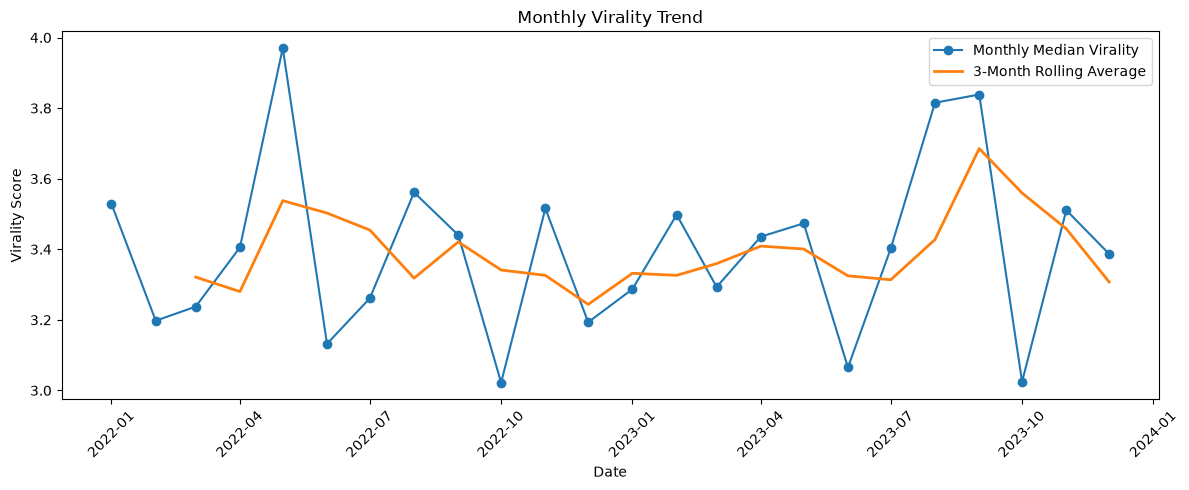

In [112]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_ts["Post_Date"],
    monthly_ts["Median_Virality"],
    marker="o",
    label="Monthly Median Virality"
)

plt.plot(
    monthly_ts["Post_Date"],
    monthly_ts["Rolling_3M_Virality"],
    linewidth=2,
    label="3-Month Rolling Average"
)

plt.title("Monthly Virality Trend")
plt.xlabel("Date")
plt.ylabel("Virality Score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [113]:
ts_data = monthly_ts[
    ["Post_Date", "Median_Virality"]
].copy()

ts_data = ts_data.set_index("Post_Date")

train = ts_data.iloc[:-6]
test = ts_data.iloc[-6:]

print("Training period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

print("\nTraining rows:", len(train))
print("Testing rows:", len(test))

Training period:
2022-01-01 00:00:00 to 2023-06-01 00:00:00

Testing period:
2023-07-01 00:00:00 to 2023-12-01 00:00:00

Training rows: 18
Testing rows: 6


In [114]:
model = ExponentialSmoothing(
    train["Median_Virality"],
    trend="add",
    damped_trend=True,
    initialization_method="estimated"
)

fitted_model = model.fit()

forecast = fitted_model.forecast(len(test))

forecast

c:\Users\Shruti Gaikwad\Documents\Data_Driven_Social_Engagement\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


2023-07-01    3.300048
2023-08-01    3.293735
2023-09-01    3.287453
2023-10-01    3.281203
2023-11-01    3.274984
2023-12-01    3.268796
Freq: MS, dtype: float64

In [115]:
comparison = pd.DataFrame({
    "Actual": test["Median_Virality"],
    "Forecast": forecast
})

comparison

,Actual,Forecast
2023-07-01,3.402439,3.300048
2023-08-01,3.815235,3.293735
2023-09-01,3.838542,3.287453
2023-10-01,3.024647,3.281203
2023-11-01,3.510819,3.274984
2023-12-01,3.386823,3.268796


In [116]:
comparison = pd.DataFrame({
    "Actual": test["Median_Virality"],
    "Forecast": forecast
})

comparison

,Actual,Forecast
2023-07-01,3.402439,3.300048
2023-08-01,3.815235,3.293735
2023-09-01,3.838542,3.287453
2023-10-01,3.024647,3.281203
2023-11-01,3.510819,3.274984
2023-12-01,3.386823,3.268796


In [117]:
mae = mean_absolute_error(
    comparison["Actual"],
    comparison["Forecast"]
)

rmse = np.sqrt(
    mean_squared_error(
        comparison["Actual"],
        comparison["Forecast"]
    )
)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

MAE: 0.3
RMSE: 0.35


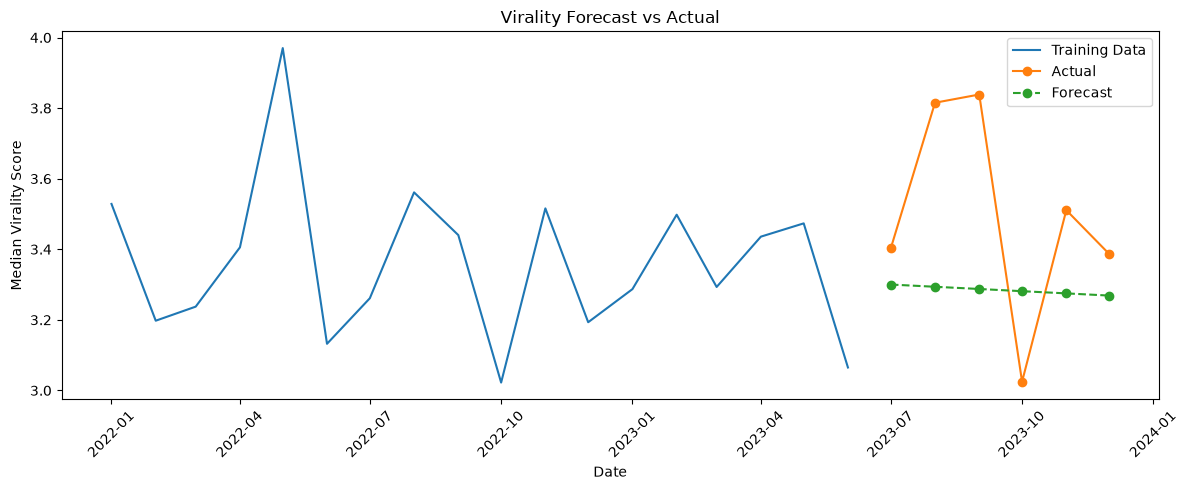

In [118]:
plt.figure(figsize=(12, 5))

plt.plot(
    train.index,
    train["Median_Virality"],
    label="Training Data"
)

plt.plot(
    test.index,
    test["Median_Virality"],
    marker="o",
    label="Actual"
)

plt.plot(
    test.index,
    forecast,
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.title("Virality Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Median Virality Score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [119]:
final_model = ExponentialSmoothing(
    ts_data["Median_Virality"],
    trend="add",
    damped_trend=True,
    initialization_method="estimated"
)

final_fitted_model = final_model.fit()

future_forecast = final_fitted_model.forecast(6)

future_dates = pd.date_range(
    start=ts_data.index.max() + pd.offsets.MonthBegin(1),
    periods=6,
    freq="MS"
)

future_forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted_Virality": future_forecast.values
})

future_forecast_df

c:\Users\Shruti Gaikwad\Documents\Data_Driven_Social_Engagement\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,Date,Forecasted_Virality
0,2024-01-01,3.428153
1,2024-02-01,3.430640
2,2024-03-01,3.433116
3,2024-04-01,3.435579
4,2024-05-01,3.438029
5,2024-06-01,3.440468


In [120]:
import os

os.makedirs("../outputs/forecasting", exist_ok=True)

monthly_ts.to_csv(
    "../outputs/forecasting/monthly_trend.csv",
    index=False
)

comparison.to_csv(
    "../outputs/forecasting/forecast_test_results.csv"
)

future_forecast_df.to_csv(
    "../outputs/forecasting/future_virality_forecast.csv",
    index=False
)

forecast_metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE"],
    "Value": [mae, rmse]
})

forecast_metrics.to_csv(
    "../outputs/forecasting/forecast_metrics.csv",
    index=False
)

print("Forecasting outputs saved successfully.")

Forecasting outputs saved successfully.


### Final Visualization & Dashboard Data Preparation Workflow

1. **Calculate KPI Summary**
* Compute top-level metrics (e.g., total posts, total views, average engagement rate, average virality score) for dashboard header cards.


2. **Prepare Platform Performance Data**
* Aggregate key metrics by platform to evaluate total reach and engagement across channels.


3. **Prepare Content-Type Performance Data**
* Group performance metrics by format (Shorts, Reels, Videos, Posts) to identify top-performing mediums.


4. **Prepare Hashtag Performance Data**
* Aggregate average virality scores, view counts, and total shares across individual hashtags.


5. **Prepare Region Performance Data**
* Group performance and engagement data geographically to analyze audience reach by region.


6. **Prepare Monthly Trends Data**
* Aggregate time-series metrics by month to drive trend lines and historical charts in Streamlit.


7. **Prepare Sentiment Summary Data**
* Summarize comment NLP outputs (positive, neutral, negative proportions) and linguistic trigger keyword frequencies.


8. **Export Viral Content Table**
* Filter and save top-tier viral posts with detailed metrics for highlight tables.


9. **Export Recommendation Table**
* Format ranked platform, content, and hashtag strategy combinations for interactive dashboard display.


10. **Save Dashboard Artifacts**
* Save all processed DataFrames as CSV files to the dashboard data folder for Streamlit integration.

In [121]:
import os

dashboard_dir = "../outputs/dashboard"

os.makedirs(dashboard_dir, exist_ok=True)

print("Dashboard output folder ready.")

Dashboard output folder ready.


In [122]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Posts",
        "Total Views",
        "Total Likes",
        "Total Shares",
        "Total Comments",
        "Median Engagement Rate",
        "Median Virality Score",
        "Total Comments Analyzed"
    ],
    "Value": [
        viral_clean["Post_ID"].nunique(),
        viral_clean["Views"].sum(),
        viral_clean["Likes"].sum(),
        viral_clean["Shares"].sum(),
        viral_clean["Comments"].sum(),
        viral_clean["Engagement_Rate"].median(),
        viral_clean["Virality_Score"].median(),
        len(sentiment_clean)
    ]
})

kpi_summary

,Metric,Value
0,Total Posts,5.000000e+03
1,Total Views,1.247033e+10
2,Total Likes,1.257375e+09
3,Total Shares,2.525978e+08
4,Total Comments,1.244420e+08
5,Median Engagement Rate,1.290969e+01
6,Median Virality Score,3.372275e+00
7,Total Comments Analyzed,3.679300e+04


In [123]:
dashboard_platform = (
    viral_clean.groupby("Platform")
    .agg(
        Posts=("Post_ID", "count"),
        Total_Views=("Views", "sum"),
        Total_Likes=("Likes", "sum"),
        Total_Shares=("Shares", "sum"),
        Total_Comments=("Comments", "sum"),
        Median_Engagement=("Engagement_Rate", "median"),
        Median_Virality=("Virality_Score", "median")
    )
    .reset_index()
    .round(2)
)

dashboard_platform

,Platform,Posts,Total_Views,Total_Likes,Total_Shares,Total_Comments,Median_Engagement,Median_Virality
0,Instagram,1212,2913744812,311627280,60976822,30249234,13.80,3.55
1,TikTok,1260,3168919406,307700467,64850003,31221158,12.52,3.26
2,Twitter,1204,3017229522,296039663,60474212,29446056,12.63,3.30
3,YouTube,1324,3370438480,342007739,66296773,33525521,12.81,3.35


In [124]:
dashboard_content = (
    viral_clean.groupby("Content_Type")
    .agg(
        Posts=("Post_ID", "count"),
        Total_Views=("Views", "sum"),
        Total_Likes=("Likes", "sum"),
        Total_Shares=("Shares", "sum"),
        Total_Comments=("Comments", "sum"),
        Median_Engagement=("Engagement_Rate", "median"),
        Median_Virality=("Virality_Score", "median")
    )
    .reset_index()
    .round(2)
)

dashboard_content

,Content_Type,Posts,Total_Views,Total_Likes,Total_Shares,Total_Comments,Median_Engagement,Median_Virality
0,Live Stream,855,2121262702,212733932,42683276,21518328,13.54,3.47
1,Post,853,2110609731,215624901,42790061,20945388,12.53,3.34
2,Reel,841,2130478961,214464309,43191967,21212884,13.31,3.48
3,Shorts,787,1956758015,195117921,39030442,19722544,12.87,3.40
4,Tweet,836,2090323471,208485417,42993352,20595684,12.53,3.26
5,Video,828,2060899340,210948669,41908712,20447141,12.89,3.37


In [125]:
dashboard_region = (
    viral_clean.groupby("Region")
    .agg(
        Posts=("Post_ID", "count"),
        Total_Views=("Views", "sum"),
        Total_Likes=("Likes", "sum"),
        Total_Shares=("Shares", "sum"),
        Total_Comments=("Comments", "sum"),
        Median_Engagement=("Engagement_Rate", "median"),
        Median_Virality=("Virality_Score", "median")
    )
    .reset_index()
    .round(2)
)

dashboard_region

,Region,Posts,Total_Views,Total_Likes,Total_Shares,Total_Comments,Median_Engagement,Median_Virality
0,Australia,602,1462197447,153140456,30575884,15065387,13.04,3.54
1,Brazil,641,1639502227,158980662,32483022,15867659,12.61,3.17
2,Canada,658,1607786982,168585301,33199698,16460300,13.06,3.40
3,Germany,566,1441300699,138283644,27830391,14065652,12.60,3.22
4,India,617,1513372283,154827086,31052494,15565417,13.20,3.52
5,Japan,592,1430193320,151895861,30527419,14699226,13.85,3.64
6,UK,647,1619027523,164351194,32649315,15599368,12.89,3.38
7,USA,677,1756951739,167310945,34279587,17118960,12.29,3.17


In [126]:
dashboard_monthly = (
    viral_clean
    .set_index("Post_Date")
    .resample("MS")
    .agg(
        Posts=("Post_ID", "count"),
        Total_Views=("Views", "sum"),
        Total_Likes=("Likes", "sum"),
        Total_Shares=("Shares", "sum"),
        Total_Comments=("Comments", "sum"),
        Median_Engagement=("Engagement_Rate", "median"),
        Median_Virality=("Virality_Score", "median")
    )
    .reset_index()
)

dashboard_monthly["Month"] = (
    dashboard_monthly["Post_Date"]
    .dt.strftime("%Y-%m")
)

dashboard_monthly

,Post_Date,Posts,Total_Views,Total_Likes,Total_Shares,Total_Comments,Median_Engagement,Median_Virality,Month
0,2022-01-01,203,470961374,48073350,10041327,5144194,12.844293,3.528480,2022-01
1,2022-02-01,197,525529116,52210884,9938693,4833358,12.228234,3.197566,2022-02
2,2022-03-01,213,546117832,52517809,11308717,5108922,12.044140,3.237438,2022-03
3,2022-04-01,182,440235659,46296196,8636495,5033859,12.971214,3.405473,2022-04
4,2022-05-01,219,503584593,55172479,11236863,5216681,14.217881,3.970175,2022-05
5,2022-06-01,225,573676463,56456236,11727626,5484131,11.962738,3.132121,2022-06
6,2022-07-01,217,546721229,55090383,10894038,5977117,12.510867,3.261186,2022-07
7,2022-08-01,215,529419638,55160039,10746797,5024494,14.244542,3.561199,2022-08
8,2022-09-01,210,515975542,49292249,10957297,5087349,12.600737,3.440142,2022-09
9,2022-10-01,204,518561891,48599133,9487662,4764866,11.460889,3.022266,2022-10


In [127]:
dashboard_sentiment = (
    sentiment_clean
    .groupby("Sentiment")
    .agg(
        Comments=("clean_comment", "count"),
        Average_Polarity=("Polarity", "mean")
    )
    .reset_index()
)

dashboard_sentiment["Percentage"] = (
    dashboard_sentiment["Comments"]
    / dashboard_sentiment["Comments"].sum()
    * 100
).round(2)

dashboard_sentiment

,Sentiment,Comments,Average_Polarity,Percentage
0,Negative,8250,-0.224005,22.42
1,Neutral,12772,-0.000807,34.71
2,Positive,15771,0.255347,42.86


In [128]:
top_viral_posts = (
    viral_clean[
        [
            "Post_ID",
            "Post_Date",
            "Platform",
            "Content_Type",
            "Hashtag",
            "Region",
            "Views",
            "Likes",
            "Shares",
            "Comments",
            "Engagement_Rate",
            "Virality_Score"
        ]
    ]
    .sort_values("Virality_Score", ascending=False)
    .head(100)
    .round(2)
)

top_viral_posts

C:\Users\Shruti Gaikwad\AppData\Local\Temp\ipykernel_2184\2575046850.py:20: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(2)


,Post_ID,Post_Date,Platform,Content_Type,Hashtag,Region,Views,Likes,Shares,Comments,Engagement_Rate,Virality_Score
4826,Post_4827,2023-09-03,TikTok,Shorts,#Viral,USA,1266,318849,1715,36121,28174.17,5689.02
1540,Post_1541,2023-11-01,Instagram,Live Stream,#Comedy,Japan,4323,301571,81786,30318,9569.16,2670.59
3686,Post_3687,2023-06-27,YouTube,Live Stream,#Tech,UK,5467,337597,79716,33748,8250.61,2233.37
2647,Post_2648,2023-05-25,YouTube,Post,#Challenge,USA,8982,353646,77267,39542,5237.75,1391.65
4691,Post_4692,2022-07-31,Twitter,Shorts,#Education,India,8162,285470,60984,43541,4778.18,1254.50
...,...,...,...,...,...,...,...,...,...,...,...,...
904,Post_905,2023-07-04,Instagram,Live Stream,#Education,Brazil,132001,419371,71316,39401,401.58,101.93
4017,Post_4018,2023-03-12,TikTok,Video,#Fashion,Brazil,110071,424227,44869,1792,427.80,101.87
4520,Post_4521,2022-06-27,Twitter,Post,#Education,USA,112559,484941,20456,26030,472.13,101.70
94,Post_95,2022-07-21,TikTok,Video,#Tech,Germany,128472,444670,64311,7956,402.37,100.50


In [129]:
top_engaging_posts = (
    viral_clean[
        [
            "Post_ID",
            "Post_Date",
            "Platform",
            "Content_Type",
            "Hashtag",
            "Region",
            "Views",
            "Likes",
            "Shares",
            "Comments",
            "Engagement_Rate",
            "Virality_Score"
        ]
    ]
    .sort_values("Engagement_Rate", ascending=False)
    .head(100)
    .round(2)
)

top_engaging_posts

C:\Users\Shruti Gaikwad\AppData\Local\Temp\ipykernel_2184\3656245219.py:20: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(2)


,Post_ID,Post_Date,Platform,Content_Type,Hashtag,Region,Views,Likes,Shares,Comments,Engagement_Rate,Virality_Score
4826,Post_4827,2023-09-03,TikTok,Shorts,#Viral,USA,1266,318849,1715,36121,28174.17,5689.02
1540,Post_1541,2023-11-01,Instagram,Live Stream,#Comedy,Japan,4323,301571,81786,30318,9569.16,2670.59
3686,Post_3687,2023-06-27,YouTube,Live Stream,#Tech,UK,5467,337597,79716,33748,8250.61,2233.37
2647,Post_2648,2023-05-25,YouTube,Post,#Challenge,USA,8982,353646,77267,39542,5237.75,1391.65
4691,Post_4692,2022-07-31,Twitter,Shorts,#Education,India,8162,285470,60984,43541,4778.18,1254.50
...,...,...,...,...,...,...,...,...,...,...,...,...
904,Post_905,2023-07-04,Instagram,Live Stream,#Education,Brazil,132001,419371,71316,39401,401.58,101.93
3630,Post_3631,2022-03-10,YouTube,Shorts,#Challenge,Japan,71395,250794,24677,5802,393.97,92.62
4,Post_5,2023-03-23,TikTok,Post,#Dance,Brazil,64866,171361,69581,6376,381.28,119.16
4278,Post_4279,2022-12-14,TikTok,Video,#Music,Australia,28280,67072,13299,23411,366.98,92.21


In [131]:
dashboard_hashtag = (
    viral_clean.groupby("Hashtag")
    .agg(
        Posts=("Post_ID", "count"),
        Total_Views=("Views", "sum"),
        Total_Likes=("Likes", "sum"),
        Total_Shares=("Shares", "sum"),
        Total_Comments=("Comments", "sum"),
        Median_Engagement=("Engagement_Rate", "median"),
        Median_Virality=("Virality_Score", "median")
    )
    .reset_index()
    .round(2)
    .sort_values("Median_Virality", ascending=False)
)

dashboard_hashtag

,Hashtag,Posts,Total_Views,Total_Likes,Total_Shares,Total_Comments,Median_Engagement,Median_Virality
1,#Comedy,505,1237321563,128075952,24956115,12523437,13.54,3.56
9,#Viral,481,1172480925,120232921,24256296,11917503,13.29,3.54
4,#Fashion,487,1181866511,121735671,24816032,11788480,13.40,3.53
2,#Dance,496,1213891935,126224505,24580747,12184262,13.35,3.44
3,#Education,525,1328894615,136722295,27168070,12959585,12.73,3.39
8,#Tech,491,1235543295,127830450,23709020,12667579,13.25,3.31
7,#Music,493,1266398079,122270318,25126055,12337077,12.67,3.31
6,#Gaming,479,1197834795,116310583,24601832,12134142,12.81,3.25
0,#Challenge,507,1242826928,122294707,25949491,12780380,12.59,3.23
5,#Fitness,536,1393273574,135677747,27434152,13149524,11.94,3.16


In [132]:
kpi_summary.to_csv(
    f"{dashboard_dir}/kpi_summary.csv",
    index=False
)

dashboard_platform.to_csv(
    f"{dashboard_dir}/platform_performance.csv",
    index=False
)

dashboard_content.to_csv(
    f"{dashboard_dir}/content_performance.csv",
    index=False
)

dashboard_hashtag.to_csv(
    f"{dashboard_dir}/hashtag_performance.csv",
    index=False
)

dashboard_region.to_csv(
    f"{dashboard_dir}/region_performance.csv",
    index=False
)

dashboard_monthly.to_csv(
    f"{dashboard_dir}/monthly_performance.csv",
    index=False
)

dashboard_sentiment.to_csv(
    f"{dashboard_dir}/sentiment_summary.csv",
    index=False
)

top_viral_posts.to_csv(
    f"{dashboard_dir}/top_viral_posts.csv",
    index=False
)

top_engaging_posts.to_csv(
    f"{dashboard_dir}/top_engaging_posts.csv",
    index=False
)

print("All dashboard CSV files saved successfully.")

All dashboard CSV files saved successfully.


In [133]:
future_forecast_df.to_csv(
    f"{dashboard_dir}/future_virality_forecast.csv",
    index=False
)

comparison.reset_index().to_csv(
    f"{dashboard_dir}/forecast_test_results.csv",
    index=False
)

print("Forecast data added to dashboard outputs.")

Forecast data added to dashboard outputs.


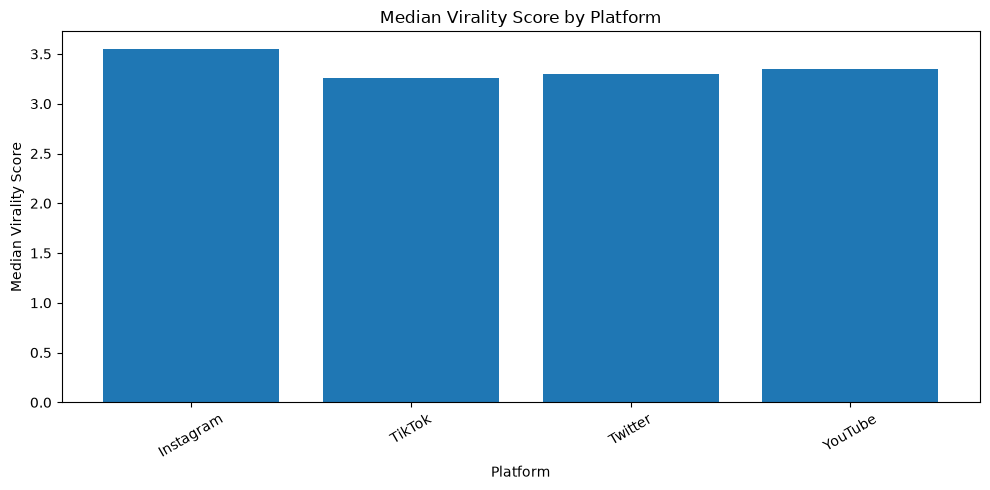

In [134]:
plt.figure(figsize=(10, 5))

plt.bar(
    dashboard_platform["Platform"],
    dashboard_platform["Median_Virality"]
)

plt.title("Median Virality Score by Platform")
plt.xlabel("Platform")
plt.ylabel("Median Virality Score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

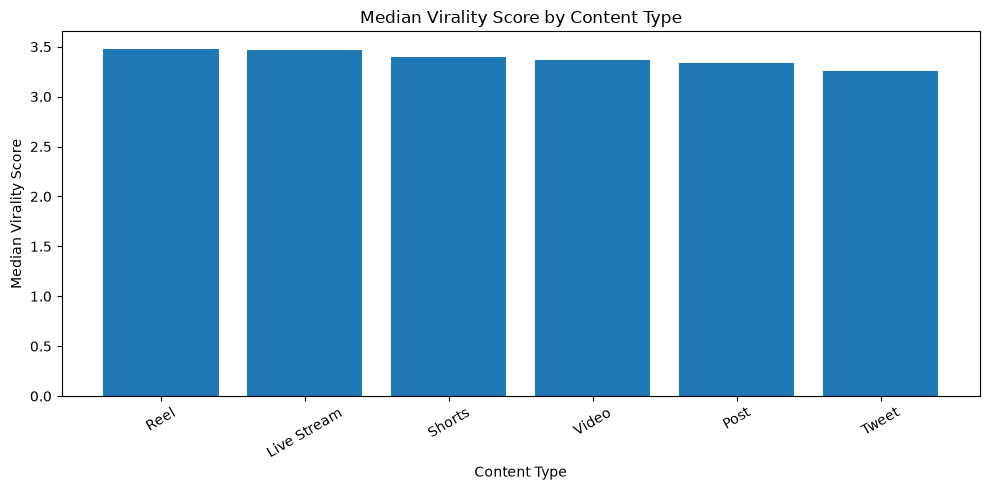

In [135]:
content_plot = dashboard_content.sort_values(
    "Median_Virality",
    ascending=False
)

plt.figure(figsize=(10, 5))

plt.bar(
    content_plot["Content_Type"],
    content_plot["Median_Virality"]
)

plt.title("Median Virality Score by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Median Virality Score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

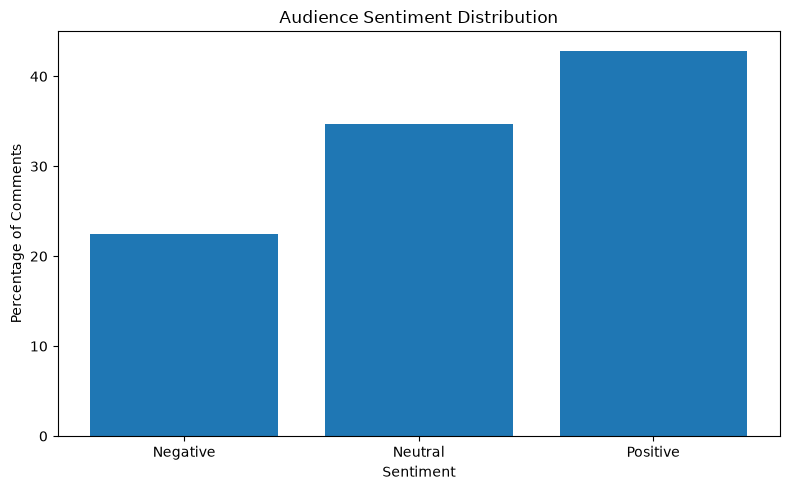

In [136]:
plt.figure(figsize=(8, 5))

plt.bar(
    dashboard_sentiment["Sentiment"],
    dashboard_sentiment["Percentage"]
)

plt.title("Audience Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Percentage of Comments")
plt.tight_layout()
plt.show()

In [137]:
print("Dashboard files:")

for file in sorted(os.listdir(dashboard_dir)):
    print(file)

Dashboard files:
content_performance.csv
forecast_test_results.csv
future_virality_forecast.csv
hashtag_performance.csv
kpi_summary.csv
monthly_performance.csv
platform_performance.csv
region_performance.csv
sentiment_summary.csv
top_engaging_posts.csv
top_viral_posts.csv
